<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA3_TP6/RA3_Trabajo_pr%C3%A1ctico_N%C2%B0_6_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejercio 1 - Optimización de una función unidimensioanl con Algoritmos Genéticos (DEAP)


##Función Objetivo:


$f(x) = |\frac{\sin x}{x}|$

- Máximo global conocido: x=0, con f(0) = 1.
- Infinitos máximos locales de amplitud decreciente (envolvente $\approx  |\frac{1}{x}| $)
- **Problema numérico crítico:** $\frac{\sin x}{x}=0$ es una indeterminación 0/0. Se resuelve sustituyendo, solo a fines de cálculo, el valor de `0` por un epsilon (1e-10) antes de dividir. Esto evita `NaN` sin alterar prácticamente el resultado (el límite real es 1).

##0. Instalación de dependencias y librerías necesarias

In [26]:
# ============================================================
# INSTALACIÓN Y CONFIGURACIÓN GLOBAL
# ============================================================
!pip install deap -q

import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools

%matplotlib inline

# Semilla maestra. DEAP usa internamente el módulo `random` de Python
# (cxBlend, mutGaussian, selTournament, selRoulette, selBest, etc.),
# por eso se fija random.seed además de np.random.seed: así se garantiza
# reproducibilidad 100% tanto en los operadores genéticos como en
# cualquier cálculo auxiliar hecho con numpy.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

##1. Paisaje de busqueda

*   cerca de $x=0$ existe una única cuenca muy6 angosta y alta (el óptimo global, $f=1$).
*   Para $|x|$ creciente aparecen infinitos óptimos locales cuya altura decae como ~$|\frac{1}{x}|$.
*   En intervalos amplios, la inmensa mayoría del espacio es "casi plana y baja": la información útil para guiar la búsqueda se concentra en una región pequeña alrededor del origen. Esto anticipa que, al ampliar el intervalo, la inicialización aleatoria tendrá cada vez menos probabilidad de ubicar individuos cerca del óptimo global.



f(0)     = 1.0
f(1e-10) = 1.0
f(pi)    = 3.8981718325193755e-17


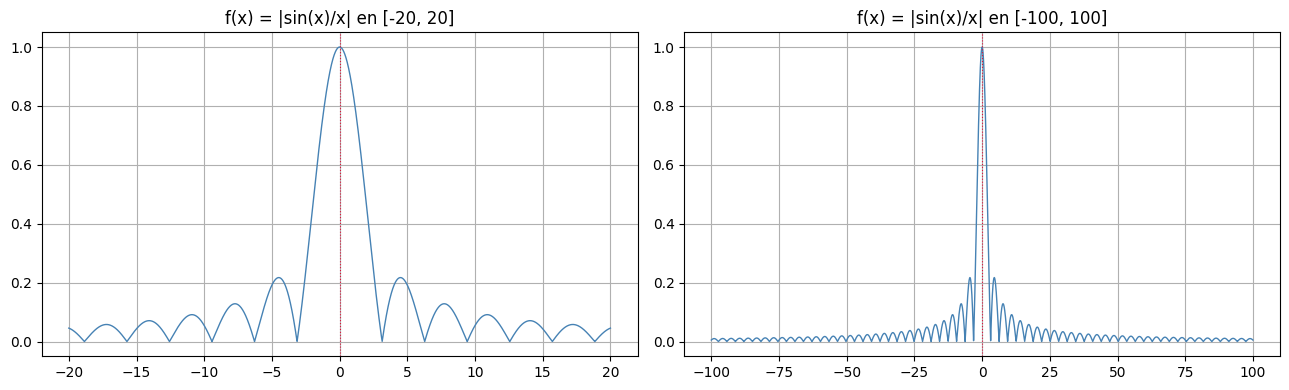

In [27]:
def objective_vec(x):
    """Versión vectorizada de f(x)=|sin(x)/x|, para graficar (acepta arrays)."""
    x = np.asarray(x, dtype=np.float64)
    x_safe = np.where(x == 0, 1e-10, x)
    return np.abs(np.sin(x_safe) / x_safe)

def objective_scalar(x):
    """Versión escalar segura, usada por la función de evaluación de DEAP."""
    x_safe = 1e-10 if x == 0.0 else x
    return abs(np.sin(x_safe) / x_safe)

print("f(0)     =", objective_scalar(0.0))
print("f(1e-10) =", objective_scalar(1e-10))
print("f(pi)    =", objective_scalar(np.pi))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (lo, hi) in zip(axes, [(-20, 20), (-100, 100)]):
    xs = np.linspace(lo, hi, 6000)
    ax.plot(xs, objective_vec(xs), lw=1, color="steelblue")
    ax.set_title(f"f(x) = |sin(x)/x| en [{lo}, {hi}]")
    ax.axvline(0, color="crimson", lw=0.8, linestyle=":")
plt.tight_layout()
plt.show()

##2. Construcción de los tipos DEAP


*   **Individuo:** Una lista de un único `float`(codificación real, natural para una variable continua).
*   **Fitness:** `FitnessMax`con `weights=(1,0,)`, porque el objetivo de este ejercicio siempre es *mazimizar* la función que se le entregue al toolbox ( esto es clave para responder más adelante qué pasa si en realidad se busca un mínimo).



In [28]:
# Se usa un guard para que la celda sea re-ejecutable sin errores
# ("Cannot create a class that already exists") dentro de Colab.
if "FitnessMax" not in dir(creator):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if "Individual" not in dir(creator):
    creator.create("Individual", list, fitness=creator.FitnessMax)


def evaluate(individual):
    """Función de evaluación que usa DEAP: siempre devuelve una tupla."""
    return (objective_scalar(individual[0]),)


def mutate_clipped(individual, mu, sigma, indpb, low, up):
    """
    Envoltorio sobre tools.mutGaussian que además recorta el resultado
    a los límites del intervalo de búsqueda. Sin este recorte, la mutación
    gaussiana podría llevar individuos fuera de los límites declarados,
    especialmente en los lóbulos cercanos al borde del intervalo.
    """
    tools.mutGaussian(individual, mu=mu, sigma=sigma, indpb=indpb)
    individual[0] = float(np.clip(individual[0], low, up))
    return (individual,)


def select_truncation(individuals, k):
    """
    Selección elitista por truncamiento: solo los mejores individuos
    de la generación actúan como padres (se repiten cíclicamente
    hasta completar k). Es la variante de selección más agresiva
    de las tres comparadas en la Sección 6.
    """
    ranked = sorted(individuals, key=lambda ind: ind.fitness.values[0], reverse=True)
    reps = int(np.ceil(k / len(ranked)))
    return (ranked * reps)[:k]

In [29]:
def build_toolbox(bounds, sigma_frac, pm, selection, tournsize=3):
    """Crea y configura un toolbox de DEAP para un experimento puntual."""
    a, b = bounds
    sigma = sigma_frac * (b - a)

    toolbox = base.Toolbox()
    toolbox.register("attr_float", random.uniform, a, b)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, 1)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)

    # Cruzamiento aritmético (blend): interpola continuamente entre dos
    # padres, lo que permite refinar la solución con precisión arbitraria
    # (a diferencia de una codificación binaria de longitud fija).
    toolbox.register("mate", tools.cxBlend, alpha=0.5)

    # Mutación gaussiana con sigma proporcional al ancho del intervalo:
    # esto es lo que le permite al operador dar "saltos grandes" cuando
    # el intervalo de búsqueda es muy amplio, y "saltos finos" cuando es chico.
    toolbox.register("mutate", mutate_clipped, mu=0.0, sigma=sigma, indpb=pm, low=a, up=b)

    if selection == "ruleta":
        toolbox.register("select", tools.selRoulette)          # proporcional al fitness
    elif selection == "torneo":
        toolbox.register("select", tools.selTournament, tournsize=tournsize)
    elif selection == "elitismo":
        toolbox.register("select", select_truncation)          # solo los mejores
    else:
        raise ValueError(f"Método de selección no reconocido: {selection}")

    return toolbox

##3. Bucle evolutivo con diagnóstico

Se opta por un bucle propio (en vez de `deap.algorithms.eaSimple`) por dos razones:
1. Permite registrar **mejor fitness, fitness medio y diversidad poblacional (std de x)** generación por generación, que es la principal herramienta de diagnóstico pedida por la consigna.
2.  Permite implementar un **criterio de parada combinado:** corte por umbral de fitness casi perfecto, o por estancamiento (`patience` generaciones sin mejora). Un número fijo de generaciones es arbitario: muy bajo corta la búsqueda antes de converger, muy alto desperdicia cómputo evaluando generaciones que ya no aportan nada. El estancamiento adapta automáticamente la duración de la corrida a la dificultad real de cada configuración.

Además, se mantiene un elitismo de preservación (`elite_preserve`, vía `tools.selBest`) independiente del método de selección de padres: el mejor individuo de cada generación se copia sin alteraciones a la siguiente, garantizando que el mejor fitness nunca empeore.






In [30]:
def run_ga_deap(bounds, pop_size=50, generations=200, pc=0.8, pm=0.1,
                 sigma_frac=0.05, selection="torneo", tournsize=3,
                 elite_preserve=1, patience=30, fitness_target=0.999999, seed=0):
    """
    AG con DEAP para maximizar objective_scalar sobre `bounds`.
    Devuelve la mejor solución, la población final y el historial
    de diagnóstico (mejor, medio, diversidad) por generación.
    """
    random.seed(seed)  # reproducibilidad total de esta corrida puntual
    toolbox = build_toolbox(bounds, sigma_frac, pm, selection, tournsize)

    pop = toolbox.population(n=pop_size)
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)

    best_hist, mean_hist, std_hist = [], [], []
    best_fit_ever, stagnant, gen_used = -np.inf, 0, 0

    for gen in range(generations):
        fits = np.array([ind.fitness.values[0] for ind in pop])
        xs = np.array([ind[0] for ind in pop])
        best_hist.append(fits.max())
        mean_hist.append(fits.mean())
        std_hist.append(xs.std())
        gen_used = gen + 1

        # --- criterio de parada ---
        if fits.max() >= fitness_target:
            break
        if fits.max() > best_fit_ever + 1e-12:
            best_fit_ever, stagnant = fits.max(), 0
        else:
            stagnant += 1
        if stagnant >= patience:
            break

        # --- elitismo de preservación ---
        elite = list(map(toolbox.clone, tools.selBest(pop, elite_preserve)))

        # --- selección de padres ---
        offspring = list(map(toolbox.clone, toolbox.select(pop, pop_size - elite_preserve)))

        # --- cruzamiento ---
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < pc:
                toolbox.mate(c1, c2)

        # --- mutación ---
        for mutant in offspring:
            toolbox.mutate(mutant)

        # reevaluación (barato: una sola función escalar por individuo)
        for ind in offspring:
            ind.fitness.values = toolbox.evaluate(ind)

        pop[:] = elite + offspring

    best_ind = tools.selBest(pop, 1)[0]
    return {
        "best_x": best_ind[0],
        "best_fitness": best_ind.fitness.values[0],
        "pop_final": np.array([ind[0] for ind in pop]),
        "fit_final": np.array([ind.fitness.values[0] for ind in pop]),
        "best_hist": np.array(best_hist),
        "mean_hist": np.array(mean_hist),
        "std_hist": np.array(std_hist),
        "generations_run": gen_used,
    }

In [43]:
def plot_evolution(res, title=""):
    gens = np.arange(len(res["best_hist"]))
    plt.figure(figsize=(8, 4))
    plt.plot(gens, res["best_hist"], label="Mejor fitness", color="seagreen")
    plt.plot(gens, res["mean_hist"], label="Fitness medio", color="darkorange", linestyle="--")
    plt.xlabel("Generación"); plt.ylabel("Fitness"); plt.title(title); plt.legend()
    plt.show()

def plot_population(res, bounds, title=""):
    a, b = bounds
    xs = np.linspace(a, b, 4000)
    plt.figure(figsize=(8, 4))
    plt.plot(xs, objective_vec(xs), color="gray", lw=1, label="f(x)")
    plt.scatter(res["pop_final"], res["fit_final"], color="crimson", s=18, zorder=5, label="Población final")
    plt.axvline(0, color="black", linestyle=":", lw=1)
    plt.xlabel("x"); plt.ylabel("f(x)"); plt.title(title); plt.legend()
    plt.show()

##4. Experimento base

Mejor x:            -0.00006330
Mejor fitness:      1.00000000
Generaciones usadas: 6


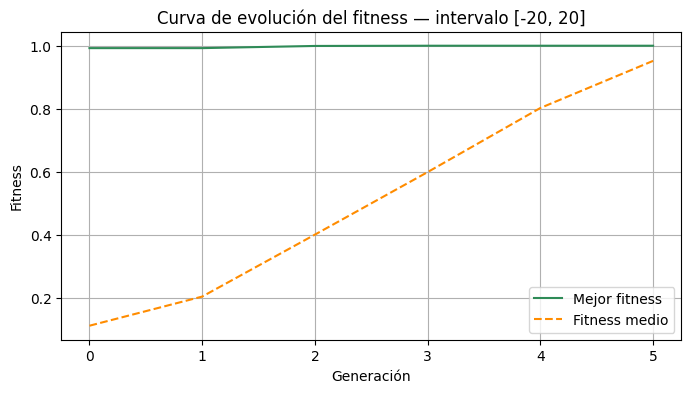

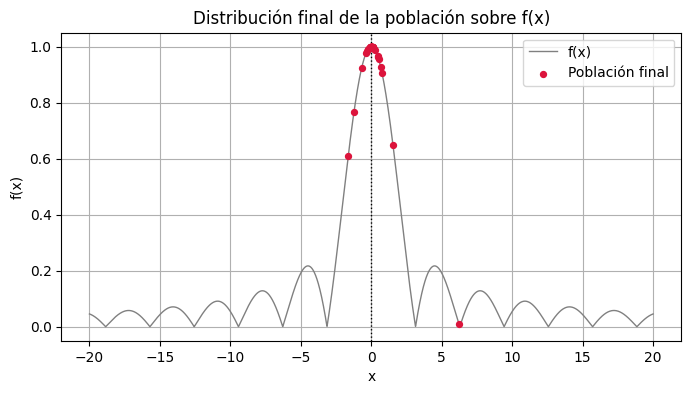

In [44]:
res_base = run_ga_deap(bounds=(-20, 20), pop_size=50, generations=150, selection="torneo",
                        pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1, patience=30, seed=SEED)

print(f"Mejor x:            {res_base['best_x']:.8f}")
print(f"Mejor fitness:      {res_base['best_fitness']:.8f}")
print(f"Generaciones usadas: {res_base['generations_run']}")

plot_evolution(res_base, "Curva de evolución del fitness — intervalo [-20, 20]")
plot_population(res_base, (-20, 20), "Distribución final de la población sobre f(x)")

-  El mejor fitness sube de forma monótona (por el elitismo de preservación) y se aplana rápidamente cerca de 1; eso, de por sí solo, ya es una señal de que el algoritmo está funcionando correctamente (una curva que retrocediera indicaría un error de implementación).
-  El fitness medio converge hacia el mejor, pero con cierto retraso: esa brecha creciente es la huella visual de que la población está perdiendo diversidad a medida que se concentra alrededor del óptimo, algo que se cuantifica con más detalle en la Sección 9.
.  En la dispersión final, casi toda la población quedea dentro del lóbulo central, lo cual es una confirmación directa de convergencia.

##5. Tamaño de población vs. ancho del intervalo

In [45]:
def run_repeated(bounds, pop_size, n_reps=10, base_seed=2000, **kwargs):
    successes, gens_ok = 0, []
    threshold = kwargs.get("fitness_target", 0.999999)
    for r in range(n_reps):
        res = run_ga_deap(bounds, pop_size=pop_size, seed=base_seed + r, **kwargs)
        if res["best_fitness"] >= threshold:
            successes += 1
            gens_ok.append(res["generations_run"])
    return successes / n_reps, (np.mean(gens_ok) if gens_ok else np.nan)


POP_SIZES = [5, 10, 20, 30, 50, 80, 120]
INTERVALS = {"[-20, 20]": (-20, 20), "[-100, 100]": (-100, 100),
             "[-1e3, 1e3]": (-1e3, 1e3), "[-1e4, 1e4]": (-1e4, 1e4)}
KW = dict(generations=200, selection="torneo", pc=0.8, pm=0.1,
          sigma_frac=0.05, elite_preserve=1, patience=40, n_reps=10)

rate_by_int, gens_by_int = {}, {}
for label, bnd in INTERVALS.items():
    rates, gens = [], []
    for p in POP_SIZES:
        r, g = run_repeated(bnd, p, **KW)
        rates.append(r); gens.append(g)
    rate_by_int[label], gens_by_int[label] = rates, gens

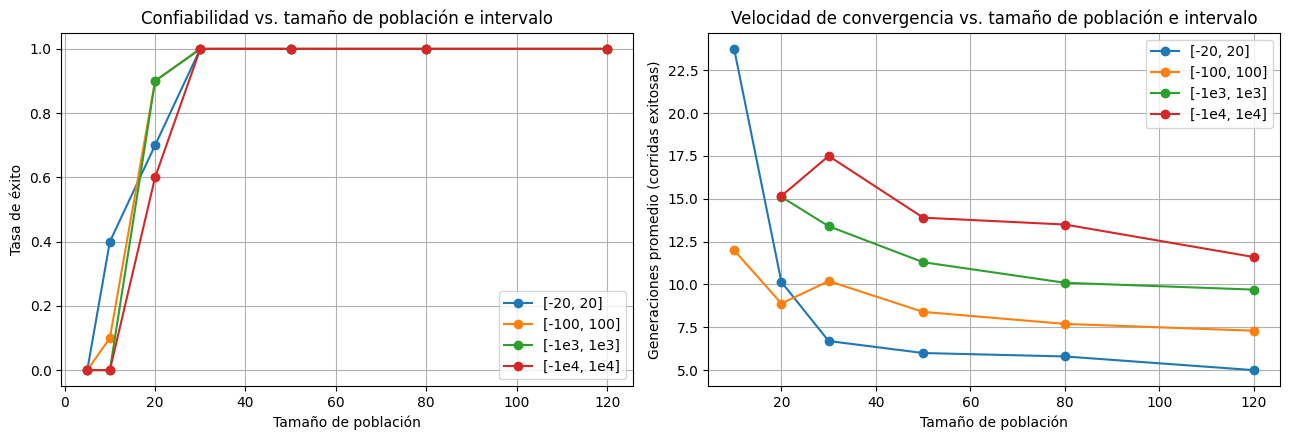

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label in INTERVALS:
    axes[0].plot(POP_SIZES, rate_by_int[label], marker="o", label=label)
axes[0].set_xlabel("Tamaño de población"); axes[0].set_ylabel("Tasa de éxito")
axes[0].set_title("Confiabilidad vs. tamaño de población e intervalo"); axes[0].legend()

for label in INTERVALS:
    axes[1].plot(POP_SIZES, gens_by_int[label], marker="o", label=label)
axes[1].set_xlabel("Tamaño de población"); axes[1].set_ylabel("Generaciones promedio (corridas exitosas)")
axes[1].set_title("Velocidad de convergencia vs. tamaño de población e intervalo"); axes[1].legend()
plt.tight_layout(); plt.show()

-  En [-20, 20] la tasa de éxito (sobre 10 semillas) ya se acerca a 1 con poblaciones de apenas 20 a 30 individuos; por debajo de 10 la confiabilidad cae notoriamente por que la inicializaicón puede no colocar a nadie dentro de la cuenca central.
-  A medida que el intervalo se ensancha (100, 10<sup>3</sup>, 10<sup>4</sup>), la curva de tasa de éxito se desplaza hacia poblacione de cada vez más grandes para mantener la misma confiabilidad: la cuenca central tiene ancho fijo mientras el intervalo crece, así que la probabilidad de "tocarla" al alzar decae aproximadamente en proporción innversa al ancho del intervalo
-  En cambio, las generaciones necesarias para converger (panel derecho, medias sobre las corridas exitosas) no crecen de forma tan dramática con el intervalo: una vez que algún individuo cae dentro de la cuenca, el cruzamiento aritmético y la mutación lo refinan en pocas decenas de generaciones casi sin importar el ancho del intervalo. Es decir, el número de generaciones depende mucho más débilmente del intervalo que la tasa de éxito, y depende del tamaño de población sobre todo a través de la velocidad con la que la selección concentra la busqueda, no de la dificultad geométrica del problema.

##6. Límite numérico de `float64`

In [47]:
print("Máximo float64 representable:", np.finfo(np.float64).max)

x_huge = 1e17
espaciado = np.spacing(x_huge)
print(f"\nEspaciado entre floats consecutivos en x={x_huge:.0e}: {espaciado:.3f}")
print(f"2*pi = {2*np.pi:.5f}  ->  ¿espaciado > 2*pi?: {espaciado > 2*np.pi}")
print(f"sin(x)              = {np.sin(x_huge):.6f}")
print(f"sin(x + espaciado)  = {np.sin(x_huge + espaciado):.6f}")

res_extreme = run_ga_deap(bounds=(-1e17, 1e17), pop_size=300, generations=200,
                           selection="torneo", pc=0.8, pm=0.1, sigma_frac=0.05,
                           elite_preserve=1, patience=40, seed=SEED)
print(f"\nMejor x: {res_extreme['best_x']:.6e}  |  Mejor fitness: {res_extreme['best_fitness']:.6e}")

Máximo float64 representable: 1.7976931348623157e+308

Espaciado entre floats consecutivos en x=1e+17: 16.000
2*pi = 6.28319  ->  ¿espaciado > 2*pi?: True
sin(x)              = -0.464530
sin(x + espaciado)  = 0.699817

Mejor x: -7.056981e-04  |  Mejor fitness: 9.999999e-01


- A magnitudes del orden de 10<sup>17</sup>, el espaciado entre `float64` consecutivos ya superan $2\pi$: ya no hay suficientes números representables para describir un período completo del seno. El paisaje deja de ser una función suave y se vuelve, en la práctica, ruido.
- A esto se suma que la probabilidad de que cualquier población finita "toque" la cuanca central (de ancho prácticamente constante) dentro de un intervalo de ancho $2×10$<sup>17</sup> es virtualmente nula.
- Conclusión: no existe un tamaño de población razonable que vuelva confiable a este AG en intervalos de esa magnitud, la limitación no es del algoritmo genético sino del soporte numérico sobre el que está implementado. "Ampliar el intervalo al máximo soportado por el lenguaje" debe entenderse, entonces, como un experimento de validación de límites y no como un objetivo alcanzable.

##7. Métodos de selección: ruleta, torneo y elitismo

In [48]:
METHODS, N_REPS, GEN_CMP = ["ruleta", "torneo", "elitismo"], 15, 100
bounds_cmp, pop_cmp = (-20, 20), 40

curves_best, curves_std = {}, {}
for method in METHODS:
    best_runs, std_runs = [], []
    for r in range(N_REPS):
        res = run_ga_deap(bounds_cmp, pop_size=pop_cmp, generations=GEN_CMP, selection=method,
                           pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                           patience=GEN_CMP, seed=3000 + r)
        bh = np.full(GEN_CMP, res["best_hist"][-1]); bh[:len(res["best_hist"])] = res["best_hist"]
        sh = np.full(GEN_CMP, res["std_hist"][-1]); sh[:len(res["std_hist"])] = res["std_hist"]
        best_runs.append(bh); std_runs.append(sh)
    curves_best[method] = np.mean(best_runs, axis=0)
    curves_std[method] = np.mean(std_runs, axis=0)

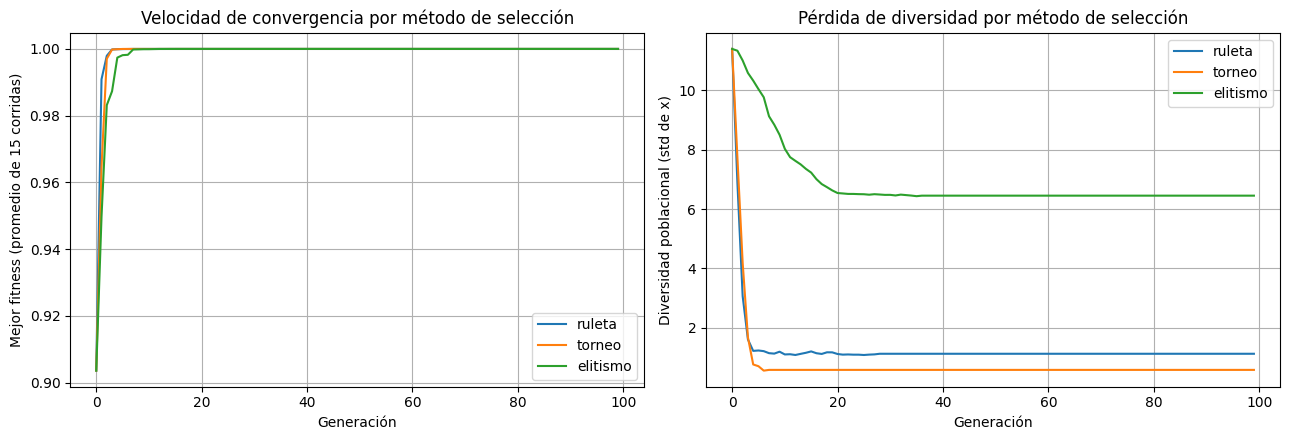

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for method in METHODS:
    axes[0].plot(curves_best[method], label=method)
axes[0].set_xlabel("Generación"); axes[0].set_ylabel("Mejor fitness (promedio de 15 corridas)")
axes[0].set_title("Velocidad de convergencia por método de selección"); axes[0].legend()

for method in METHODS:
    axes[1].plot(curves_std[method], label=method)
axes[1].set_xlabel("Generación"); axes[1].set_ylabel("Diversidad poblacional (std de x)")
axes[1].set_title("Pérdida de diversidad por método de selección"); axes[1].legend()
plt.tight_layout(); plt.show()

- **Elitismo (truncamiento, `select_truncation`)**: converge más rápido al inicio por que solo cruza a los mejores individuos disponibles, pero su curva de diversidad colapsa casi verticalmente: es el método con mayor riesgo de **convergencia prematura**, al descartar de plano cualquier aporte exploratorio de individuos mediocres.
- **Torneo (`tools.selfTournament`)**: equilibrio entre velocidad y diversidad; la presión selectiva se puede ajustar con `tournsize` (a mayor tamaño de torneo, más se parece al elitismo).
- **Ruleta (`tools.selRoulette`): la más lenta de las tres en este problema, por que al estar en el fitnessacotado entre [0,1] y muy concentrado en valores bajos en intervalos amplios, las diferencias relativas de probabilidad entre individuos "buenos" y "regulares" se diluyen. A cambio, mntiene diversidad por más generaciones, reduciendo el riesgo de quedar atrapada prematuramente en un óptimo local.

##8. Probabilidad de mutación

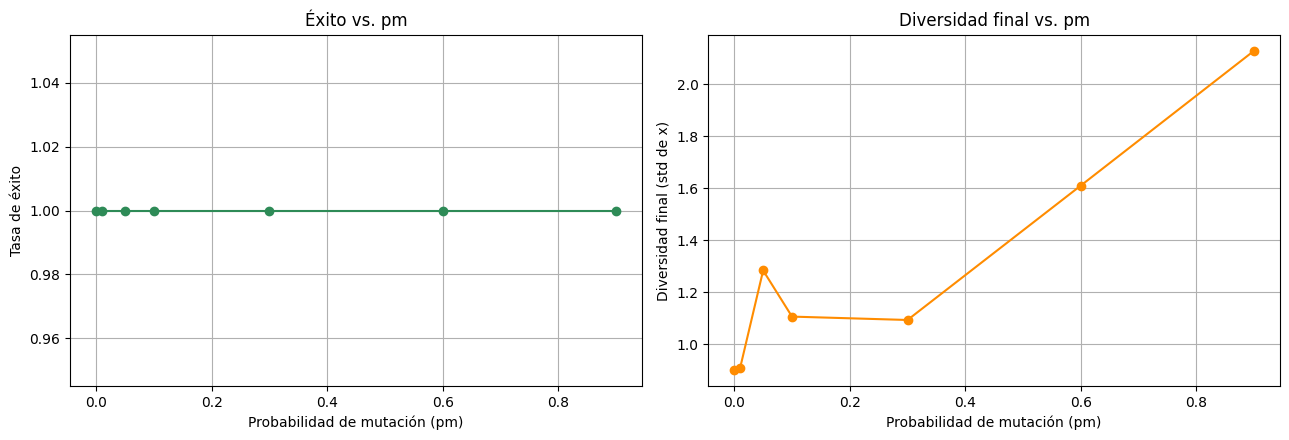

In [50]:
PM_VALUES = [0.0, 0.01, 0.05, 0.1, 0.3, 0.6, 0.9]
bounds_pm, pop_pm, n_reps_pm = (-20, 20), 40, 15

rate_pm, diversity_pm = [], []
for pm in PM_VALUES:
    successes, final_stds = 0, []
    for r in range(n_reps_pm):
        res = run_ga_deap(bounds_pm, pop_size=pop_pm, generations=150, selection="torneo",
                           pc=0.8, pm=pm, sigma_frac=0.05, elite_preserve=1,
                           patience=40, seed=4000 + r)
        if res["best_fitness"] >= 0.999999:
            successes += 1
        final_stds.append(res["std_hist"][-1])
    rate_pm.append(successes / n_reps_pm)
    diversity_pm.append(np.mean(final_stds))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(PM_VALUES, rate_pm, marker="o", color="seagreen")
axes[0].set_xlabel("Probabilidad de mutación (pm)"); axes[0].set_ylabel("Tasa de éxito")
axes[0].set_title("Éxito vs. pm")

axes[1].plot(PM_VALUES, diversity_pm, marker="o", color="darkorange")
axes[1].set_xlabel("Probabilidad de mutación (pm)"); axes[1].set_ylabel("Diversidad final (std de x)")
axes[1].set_title("Diversidad final vs. pm")
plt.tight_layout(); plt.show()

- Con $p_m =0$, el AG depende exlusivamente del cruzamiento y la diversidad inicial: puede converger razonablemente bien si esa diversidad alcanza, pero pierde toda capacidad de escapar si la población entera queda en un mismo óptimo local.
- $p_m$ bajo $(\approx 0,01 - 0,1)$ resulta lo más efectivo: aporta exploración suficiente sin destruir el progreso de la selección y el cruzamiento.
- $p_m$ alto $(\geq 0,3 - 0,6)$ degrada el desempeño: la diversidad final se mantiene artificialmente elevada (los buenos individuos son reubicados constantemente el alzar) y la tasa de éxito cae, por que el algoritmo se acerca cada vez más a una búsqueda puramente aletoria.
- Para este problema, un rango razonable es $p_m ≈0,05 - 0,15$, combinado con σ proporcional al ancho del intervalo: suficiente para escapar de lóbulos secundarios sin destruir la convergencia fina cerca del óptimo.

##9. Criterio de parada. estancamiento vs. número fijo de generaciones

In [51]:
bounds_stop, pop_stop = (-20, 20), 50

res_patience = run_ga_deap(bounds_stop, pop_size=pop_stop, generations=500, selection="torneo",
                            pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                            patience=30, fitness_target=0.999999, seed=5000)

res_fixed = run_ga_deap(bounds_stop, pop_size=pop_stop, generations=500, selection="torneo",
                         pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                         patience=500, fitness_target=1.1, seed=5000)  # umbral inalcanzable

print(f"Criterio por estancamiento -> {res_patience['generations_run']} generaciones, "
      f"fitness={res_patience['best_fitness']:.6f}")
print(f"Criterio fijo (500 gens)    -> {res_fixed['generations_run']} generaciones, "
      f"fitness={res_fixed['best_fitness']:.6f}")

Criterio por estancamiento -> 4 generaciones, fitness=1.000000
Criterio fijo (500 gens)    -> 500 generaciones, fitness=1.000000


- El criterio implementado en `run_ga_deap` combina dos señales: un umbral de fitness casi perfecto y un contador de estancamiento (`patience`) que corta la busqueda si no hay mejora durante 30 generaciones consecutivas. Ninguno por separado es robusto: un umbral fijo puede no alcanzarse nunca con una mala configuración (la corrida seguiría hasta el límite de generaciones, gastando cómputo en vano), y un número fijo de generaciones puede quedar corto para algunas configuraciones y excesivamente largo para otras.
- El experimento confirma la ganancia de eficiencia: el criterio por estancamiento corta muchísimas generaciones antes que el límite fijo de 500, sin sacrificar la calidad de la solución encontrada.

##10. Reformulación como problema de minimización

In [52]:
def evaluate_min(individual):
    """
    g(x) = 1 - f(x). Como f(x) está acotada en [0,1], g también lo está,
    y se maximiza exactamente donde f se minimiza (f(x)=0, en x=k*pi, k!=0).
    """
    return (1.0 - objective_scalar(individual[0]),)

bounds_min = (-20, 20)
toolbox_min = build_toolbox(bounds_min, sigma_frac=0.05, pm=0.1, selection="torneo")
toolbox_min.unregister("evaluate")
toolbox_min.register("evaluate", evaluate_min)

# Reutilizamos la misma lógica de run_ga_deap, pero con la función de evaluación
# transformada. No fue necesario tocar selección, cruzamiento ni mutación.
def run_ga_deap_custom_eval(bounds, toolbox, pop_size=60, generations=150,
                             pc=0.8, pm=0.1, elite_preserve=1, patience=40,
                             fitness_target=0.999999, seed=6000):
    random.seed(seed)
    pop = toolbox.population(n=pop_size)
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)
    best_hist, mean_hist, std_hist, stagnant, best_ever, gen_used = [], [], [], 0, -np.inf, 0
    for gen in range(generations):
        fits = np.array([ind.fitness.values[0] for ind in pop])
        xs = np.array([ind[0] for ind in pop])
        best_hist.append(fits.max()); mean_hist.append(fits.mean()); std_hist.append(xs.std())
        gen_used = gen + 1
        if fits.max() >= fitness_target:
            break
        if fits.max() > best_ever + 1e-12:
            best_ever, stagnant = fits.max(), 0
        else:
            stagnant += 1
        if stagnant >= patience:
            break
        elite = list(map(toolbox.clone, tools.selBest(pop, elite_preserve)))
        offspring = list(map(toolbox.clone, toolbox.select(pop, pop_size - elite_preserve)))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < pc:
                toolbox.mate(c1, c2)
        for mutant in offspring:
            toolbox.mutate(mutant)
        for ind in offspring:
            ind.fitness.values = toolbox.evaluate(ind)
        pop[:] = elite + offspring
    best_ind = tools.selBest(pop, 1)[0]
    return {"best_x": best_ind[0], "best_fitness": best_ind.fitness.values[0],
            "pop_final": np.array([i[0] for i in pop]),
            "fit_final": np.array([i.fitness.values[0] for i in pop]),  # OJO: esto es g(x), no f(x)
            "best_hist": np.array(best_hist), "mean_hist": np.array(mean_hist),
            "std_hist": np.array(std_hist), "generations_run": gen_used}

res_min = run_ga_deap_custom_eval(bounds_min, toolbox_min)
k_aprox = round(res_min["best_x"] / np.pi)
print(f"x encontrado: {res_min['best_x']:.6f}  (~{k_aprox}*pi = {k_aprox*np.pi:.6f})")
print(f"f(x) real en ese punto: {objective_scalar(res_min['best_x']):.3e}")

x encontrado: 9.424778  (~3*pi = 9.424778)
f(x) real en ese punto: 1.676e-08


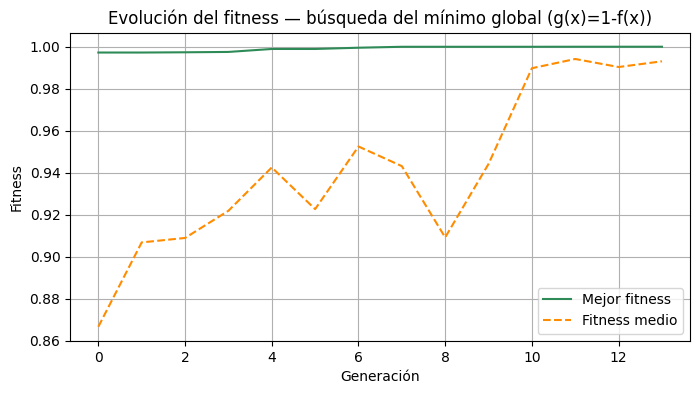

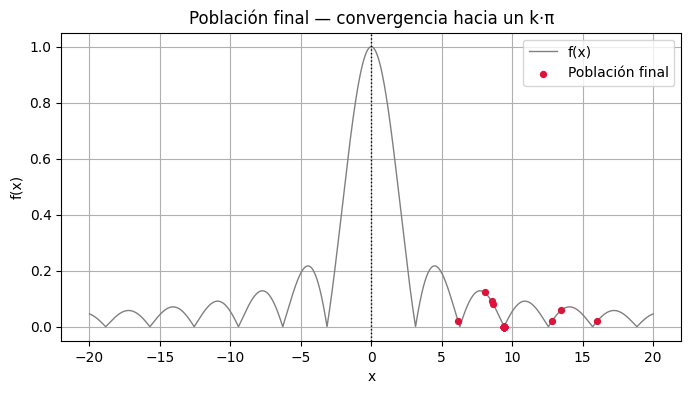

In [53]:
def plot_population_min(res, bounds, title=""):
    """
    Variante de plot_population para el caso de minimización.

    IMPORTANTE: res['fit_final'] en este experimento contiene g(x)=1-f(x)
    (el fitness que efectivamente maximizó el AG), NO f(x). Si se usara
    fit_final como coordenada y, los puntos aparecerían "flotando" muy por
    encima de la curva graficada (que sí es f(x)), dando una imagen
    visualmente incorrecta aunque las posiciones en x sean correctas.

    Por eso, para graficar la población sobre la curva de f(x), se recalcula
    la altura de cada punto evaluando f(x) directamente sobre pop_final.
    """
    a, b = bounds
    xs = np.linspace(a, b, 4000)
    y_real = objective_vec(res["pop_final"])  # <- f(x), coherente con la curva graficada

    plt.figure(figsize=(8, 4))
    plt.plot(xs, objective_vec(xs), color="gray", lw=1, label="f(x)")
    plt.scatter(res["pop_final"], y_real, color="crimson", s=18, zorder=5,
                label="Población final")
    plt.axvline(0, color="black", linestyle=":", lw=1)
    plt.xlabel("x"); plt.ylabel("f(x)"); plt.title(title); plt.legend()
    plt.show()


plot_evolution(res_min, "Evolución del fitness — búsqueda del mínimo global (g(x)=1-f(x))")
plot_population_min(res_min, bounds_min, "Población final — convergencia hacia un k·π")

- No se modificó ningún operador del AG (selección, cruzamiento, mutación, criterio de parada): el toolbox de DEAP siempre maximiza la función registrada en `toolbox.evaluate`, por construcción del `FitnessMax`.
- Alcanzó con **transformar la función objetivo:** $g(x) = 1 - f(x)$ también queda acotada en [0, 1] (compatible con `selRoulette`) y se maximiza exactamente donde $f(x)$ vale 0, es decir, en $x = k\pi, k \neq 0$.
- El AG converge hacia alguno de esos infinitos ceros, no necesariamente el más cercano a 0, dependiendo de que cuenca capturó antes a la mayoría de la población.

## 11. Diversidad poblacional vs. convergencia del fitness

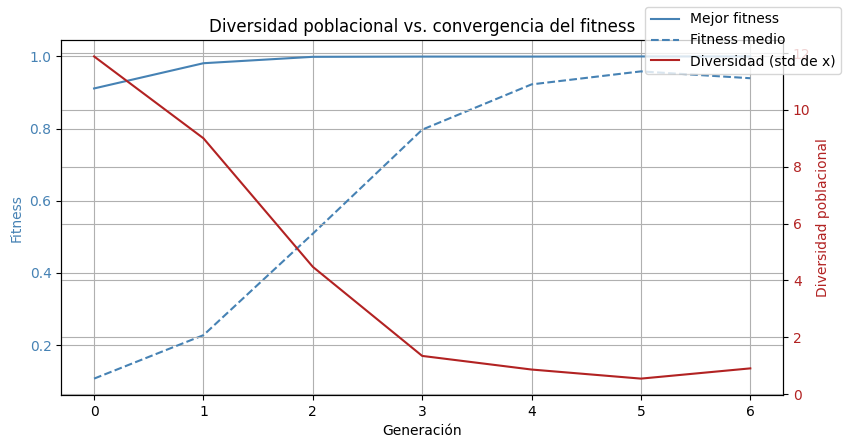

Generación de colapso de diversidad (std<0.400): 0
Generación de convergencia del fitness (>=0.999999): 6


In [55]:
res_div = run_ga_deap((-20, 20), pop_size=50, generations=150, selection="torneo",
                       pc=0.8, pm=0.1, sigma_frac=0.05, elite_preserve=1,
                       patience=150, seed=7000)  # patience alto para ver la curva completa

gens = np.arange(len(res_div["best_hist"]))
fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax1.plot(gens, res_div["best_hist"], color="steelblue", label="Mejor fitness")
ax1.plot(gens, res_div["mean_hist"], color="steelblue", linestyle="--", label="Fitness medio")
ax1.set_xlabel("Generación"); ax1.set_ylabel("Fitness", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(gens, res_div["std_hist"], color="firebrick", label="Diversidad (std de x)")
ax2.set_ylabel("Diversidad poblacional", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

fig.legend(loc="upper right")
plt.title("Diversidad poblacional vs. convergencia del fitness")
plt.tight_layout(); plt.show()

umbral_div = 0.01 * (20 - (-20))
gen_colapso = int(np.argmax(res_div["std_hist"] < umbral_div))
gen_converge = int(np.argmax(res_div["best_hist"] >= 0.999999))
print(f"Generación de colapso de diversidad (std<{umbral_div:.3f}): {gen_colapso}")
print(f"Generación de convergencia del fitness (>=0.999999): {gen_converge}")

* Las curvas de diversidad y de fitness medio están fuertemente acopladas: ambas caen/suben de forma muy correlacionada, porque son consecuencia de la misma dinámica de selección — a medida que se concentran copias de los mejores individuos, la varianza de $x$ baja y el fitness medio sube hacia el del mejor individuo.
* En este problema, el colapso de diversidad ocurre prácticamente en simultáneo con la **convergencia del fitness**, lo cual es una buena señal de funcionamiento correcto: indica que la convergencia se debe a haber encontrado realmente el óptimo global, y no a una pérdida de diversidad prematura impuesta por una presión selectiva mal calibrada (el fenómeno que sí se observó con selección puramente elitista en la Sección 7).
* En conjunto, esto es lo que da confianza en la implementación: una curva de mejor fitness monótona y acotada en 1, una curva de fitness medio que la persigue sin oscilaciones erráticas, y una pérdida de diversidad que llega *después* (no antes) de que el algoritmo ya encontró una solución de alta calidad.